### Dataset Iris
#### É um conjunto de dados clássicos na área de Machine Learnin, introduzido por Ronald Fischer em 1936.
#### Ele contém informações sobre três espécies de flores:
#### - Setosa
#### - Versicolor
#### - Virginica

#### Caracteristicas(features):
#### Comprimento da sépala(cm), largura da sépala(cm), comprimento da pétala (cm), largura da pétala(cm)
#### Objetivo: Classificar a espécie da flor com base nessas medidas
#### ---------------------------------------------------------------------------------------------------------

##### 1. Importar as bibliotecas e carregar os dados

In [58]:
# Instalando o pacote
%pip install scikit-learn
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [78]:
# Importando bibliotecas
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns
import matplotlib.pyplot as plt

# Carregando o dataset
iris = load_iris()
x = iris.data # Features(medidas)
y = iris.target # Target(espécies: 0 = setosa, 1 = versicolor, 2 = virginica)

# Convertendo para Dataframe(visualização)
df = pd.DataFrame(x, columns=iris.feature_names)
df['Especie'] = y # Adicionando coluna de Espécies

#### 2. Exporar dados com Pandas

In [60]:
print("Primeiras linhas do dataset: ")
print(df.head)

Primeiras linhas do dataset: 
<bound method NDFrame.head of      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  5.1               3.5                1.4               0.2   
1                  4.9               3.0                1.4               0.2   
2                  4.7               3.2                1.3               0.2   
3                  4.6               3.1                1.5               0.2   
4                  5.0               3.6                1.4               0.2   
..                 ...               ...                ...               ...   
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5.9               3.0         

In [61]:
print("\nInformações estatísticas: ")
print(df.describe())


Informações estatísticas: 
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     Especie  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [62]:
print("\nDistribuição das espécies: ")
print(df['Especie'].value_counts())


Distribuição das espécies: 
Especie
0    50
1    50
2    50
Name: count, dtype: int64


#### 3. Visualizar relações entre as features com o Seaborn

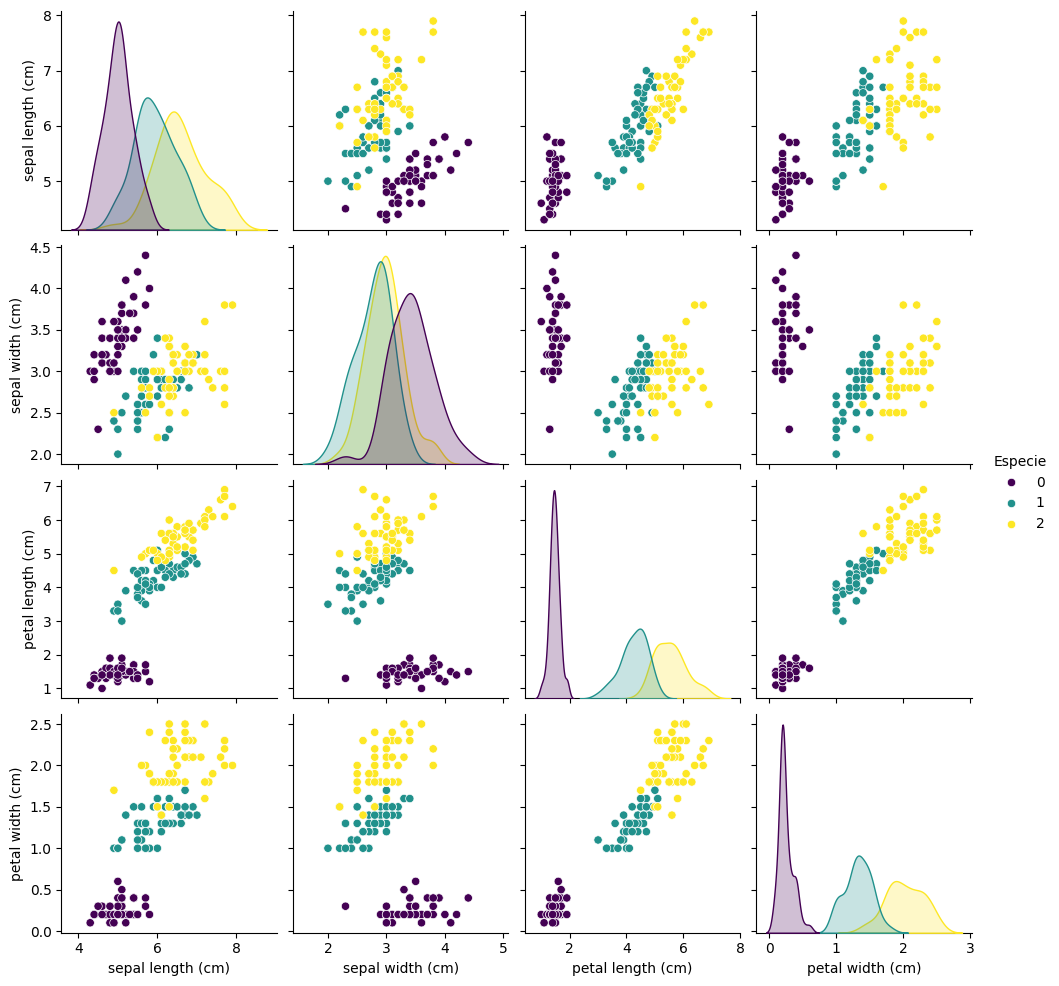

In [63]:
# Visualizar relações entre as features
sns.pairplot(df, hue='Especie', palette='viridis')

#### 4. Pré processamento
#### Dividindo os dados em treino de 70% e teste de 30%, garantindo que o modelo seja avaliado em dados não vistos.

In [ ]:
# Separar os 70% para TREINO e 30% para teste
x_train_, x_test, y_train, y_test = train_test_split(
    x, y ,test_size=0.3, random_state=42) # A busca do alinhamento perfeito

##### 5. Escolhendo e treinando um modelo
#### Vamos usar o K-Nearest Neighbors(KNN), um algoritmo simples para classificação

In [ ]:
# Inicializar o modelo (k-3 vizinhos)
modelo = KNeighborsClassifier(n_neighbors=3)   # Objeto do modelo treinado

# Treinando o modelo
modelo.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

#### O KNN classifica as amostras com base nos vizinhos mais próximos. O valor do K=3 é arbitrário. Em projetos reais testariamos múltiplos valores. O método *fit()* ajusta o modelo aos dado, aprendendo a relação entre características e espédes. 

#### 6. Fazer previsões e avaliar

In [ ]:
# Prever espécies no conjunto de teste
y_pred = modelo.predict(x_test)

# Calculando acurácia (Quantidade de acertos)
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {acuracia:.2f}")

Acurácia do modelo: 0.93


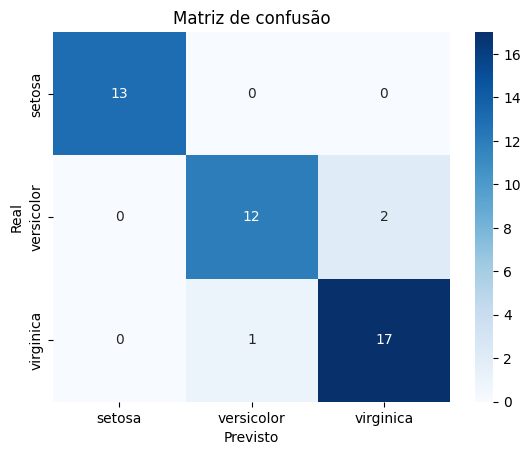

In [ ]:
# Matriz de confusão
matriz_confusao = confusion_matrix(y_test, y_pred)  # Onde ele está acertando e errando
sns.heatmap(matriz_confusao, annot=True, cmap='Blues', fmt='d',
            xticklabels=iris.target_names, yticklabels=iris.target_names)

plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de confusão')
plt.show()

In [80]:
# Relatório de classificação
print("\nRelatório de classificação")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Relatório de classificação
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.92      0.86      0.89        14
   virginica       0.89      0.94      0.92        18

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.94        45
weighted avg       0.93      0.93      0.93        45



#### Acurácia: 93% indicando que o modelo erra em poucas amostras;
#### Matriz de confusão: Mostra quais classes são confundidas (Versicolor X Virginica);
#### Relatório: Precisão de recall próximo de 1 confirma que o modelo é robusto para todas as classes.

### 7. Interpretação dos resultados
#### O modelo tem alta performance, mas com espaço de otimização;
#### A altura da acurácia reflete a simplicidade do dataset, mas em problemas reais(dados complexos), ajustar hiperparâmetros(testar k=5 ou k=7) ou usar algoritmos como SVM/árvores seria crucial;
#### A matrix de confusão direciona melhorias como coletar mais dados para clases confundidas;
#### Esse fluxo mostra o dado completo de um projeto de Machine Learning: Carregar dados -> Explorar -> Pré-processar -> Treinar -> Avaliar -> Iterar.
##### "A ciência das perguntas certas"